In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

DATA_PROC = Path("data/processed")
listings  = pd.read_csv(DATA_PROC / "listings_clean.csv", low_memory=False)

print("✅ Libraries loaded!")
print(f"Rows: {listings.shape[0]:,}")
print(f"Columns: {listings.shape[1]}")

✅ Libraries loaded!
Rows: 5,487
Columns: 61


In [8]:
# Select features to train the model on
FEATURES = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "calculated_host_listings_count",
    "availability_365",
]

TARGET = "price"

# Keep only the columns we need
model_df = listings[FEATURES + [TARGET]].dropna()

print(f"Features  : {len(FEATURES)}")
print(f"Rows      : {model_df.shape[0]:,}")
print(f"Target    : {TARGET}")
print("✅ Features selected!")

Features  : 12
Rows      : 5,487
Target    : price
✅ Features selected!


In [9]:
# Splitting the dataset for training
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows : {X_train.shape[0]:,}")
print(f"Testing rows  : {X_test.shape[0]:,}")
print("✅ Data split complete!")

Training rows : 4,389
Testing rows  : 1,098
✅ Data split complete!


In [10]:
# Training 
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained!")

✅ Model trained!


In [11]:
# Measuring Accuracy
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("-" * 30)
print(f"MAE : €{mae:.2f}")
print(f"R²  : {r2:.3f}")
print("-" * 30)

if r2 > 0.7:
    print("✅ Good model!")
elif r2 > 0.5:
    print("⚠️ Decent model, could be improved")
else:
    print("❌ Model needs improvement")

MODEL PERFORMANCE
------------------------------
MAE : €96.46
R²  : 0.444
------------------------------
❌ Model needs improvement


In [12]:
# Add room_type and neighbourhood as features
listings["room_type_enc"] = listings["room_type"].astype("category").cat.codes
listings["neighbourhood_enc"] = listings["neighbourhood_cleansed"].astype("category").cat.codes

FEATURES_V2 = FEATURES + ["room_type_enc", "neighbourhood_enc"]

model_df2 = listings[FEATURES_V2 + [TARGET]].dropna()

X2 = model_df2[FEATURES_V2]
y2 = model_df2[TARGET]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = RandomForestRegressor(n_estimators=200, random_state=42)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("IMPROVED MODEL PERFORMANCE")
print("-" * 30)
print(f"MAE : €{mae2:.2f}")
print(f"R²  : {r2_2:.3f}")
print("-" * 30)

if r2_2 > 0.7:
    print("✅ Good model!")
elif r2_2 > 0.5:
    print("⚠️ Decent model, could be improved")
else:
    print("❌ Model needs improvement")

IMPROVED MODEL PERFORMANCE
------------------------------
MAE : €85.52
R²  : 0.537
------------------------------
⚠️ Decent model, could be improved


In [13]:
# Log transform the target to reduce skew
y_log = np.log1p(y2)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X2, y_log, test_size=0.2, random_state=42
)

model3 = RandomForestRegressor(n_estimators=200, random_state=42)
model3.fit(X_train3, y_train3)

# Predict and reverse the log transformation
y_pred3 = np.expm1(model3.predict(X_test3))
y_actual3 = np.expm1(y_test3)

mae3 = mean_absolute_error(y_actual3, y_pred3)
r2_3 = r2_score(y_actual3, y_pred3)

print("LOG TRANSFORMED MODEL PERFORMANCE")
print("-" * 30)
print(f"MAE : €{mae3:.2f}")
print(f"R²  : {r2_3:.3f}")
print("-" * 30)

if r2_3 > 0.7:
    print("✅ Good model!")
elif r2_3 > 0.5:
    print("⚠️ Decent model, could be improved")
else:
    print("❌ Model needs improvement")

LOG TRANSFORMED MODEL PERFORMANCE
------------------------------
MAE : €80.27
R²  : 0.542
------------------------------
⚠️ Decent model, could be improved


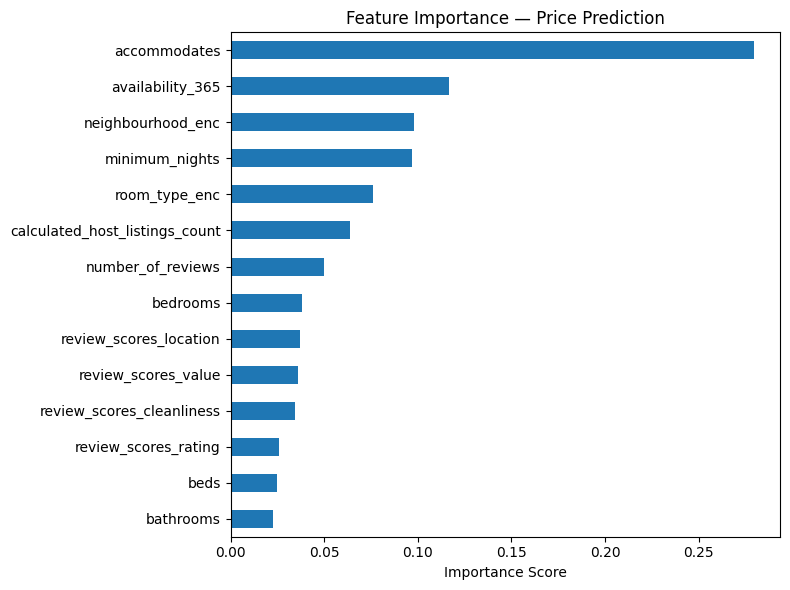

✅ Chart saved!


In [14]:
# Feature importance
feat_imp = pd.Series(model3.feature_importances_, 
                     index=FEATURES_V2).sort_values()

feat_imp.plot(kind="barh", figsize=(8, 6), 
              title="Feature Importance — Price Prediction")

plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150)
plt.show()

print("✅ Chart saved!")

In [15]:
print("MODEL SUMMARY")
print("-" * 40)
print(f"Features used  : {len(FEATURES_V2)}")
print(f"Training rows  : {X_train3.shape[0]:,}")
print(f"Testing rows   : {X_test3.shape[0]:,}")
print(f"MAE            : €{mae3:.2f}")
print(f"R²             : {r2_3:.3f}")
print("-" * 40)
print("Top 3 price drivers:")
top3 = feat_imp.sort_values(ascending=False).head(3)
for feat, score in top3.items():
    print(f"  {feat:<35} {score:.3f}")
print("-" * 40)
print("✅ Model notebook complete!")

MODEL SUMMARY
----------------------------------------
Features used  : 14
Training rows  : 4,389
Testing rows   : 1,098
MAE            : €80.27
R²             : 0.542
----------------------------------------
Top 3 price drivers:
  accommodates                        0.279
  availability_365                    0.116
  neighbourhood_enc                   0.098
----------------------------------------
✅ Model notebook complete!
